In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 다항회귀(독립변수가 여러개)

## 1. 다중선형회귀

선형회귀 모델의 결정계수 (R²): 0.7064
      feature  coefficient
0  horsepower    -0.047303
1      weight    -0.005794


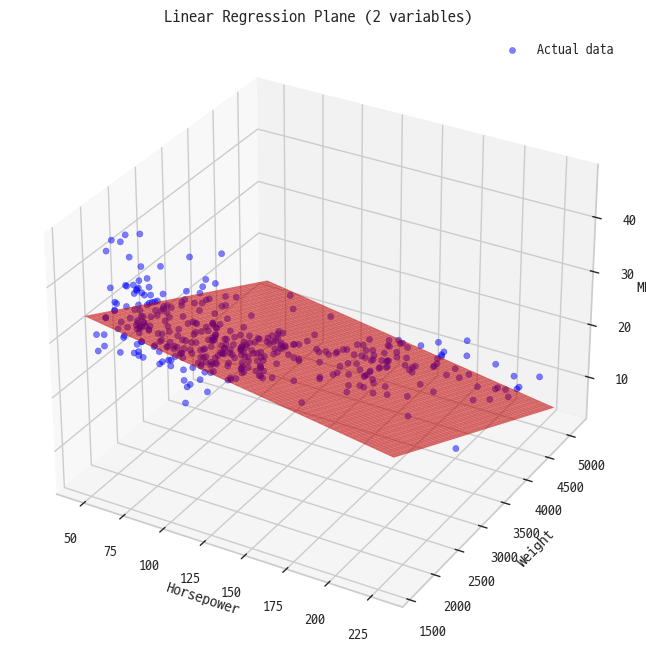

In [4]:
# 1.CSV 불러오기
df = pd.read_csv("../../data/mpg_clean.csv")

# 2.독립변수(X), 종속변수(y)
X = df[['horsepower', 'weight']]  
y = df['mpg']                    

# 3.선형회귀 모델 학습
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 4.결정계수(R²)
r2 = model.score(X, y)
print(f"선형회귀 모델의 결정계수 (R²): {r2:.4f}")

# 5.회귀계수 확인
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
print(coef_df)

# 6.3D 시각화 (실제 데이터 + 회귀 평면)
hp_range = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 50)
wt_range = np.linspace(df['weight'].min(), df['weight'].max(), 50)
hp_grid, wt_grid = np.meshgrid(hp_range, wt_range)

# 7.회귀 평면 예측
X_grid = pd.DataFrame({'horsepower': hp_grid.ravel(),'weight': wt_grid.ravel()})  ## 2차원 배열 → 1차원 벡터로 평탄화(flatten)
y_grid_pred = model.predict(X_grid).reshape(hp_grid.shape)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# 실제 데이터 산점도
ax.scatter(df['horsepower'], df['weight'], df['mpg'], color='blue', alpha=0.5, label='Actual data')

# 선형회귀 평면
ax.plot_surface(hp_grid, wt_grid, y_grid_pred, color='red', alpha=0.6)

ax.set_xlabel('Horsepower')
ax.set_ylabel('Weight')
ax.set_zlabel('MPG')
ax.set_title('Linear Regression Plane (2 variables)')
plt.legend()
plt.show()

## 2. 다항회귀 (독립변수 2개)

2차 다항 회귀 모델의 결정계수 (R²): 0.7494
             feature   coefficient
0         horsepower -2.645660e-01
1             weight -1.019085e-02
2       horsepower^2  2.820050e-04
3  horsepower weight  3.593787e-05
4           weight^2  2.438016e-07


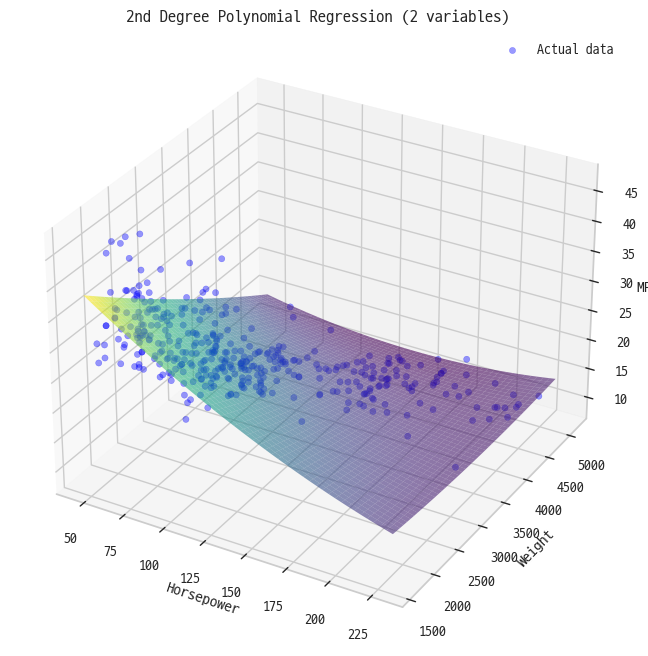

In [6]:
# 1.CSV 불러오기
df = pd.read_csv("../../data/mpg_clean.csv")

# 2.독립변수(X), 종속변수(y)
X = df[['horsepower', 'weight']]
y = df['mpg']

# 3.2차 다항 변환
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 4.선형회귀 모델 학습
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

# 5.결정계수(R²)
r2 = model.score(X_poly, y)
print(f"2차 다항 회귀 모델의 결정계수 (R²): {r2:.4f}")

# 6.다항식의 항 이름과 계수 확인
feature_names = poly.get_feature_names_out(X.columns)
coef_df = pd.DataFrame({'feature': feature_names,'coefficient': model.coef_})
print(coef_df)

# 7.3D 시각화 (곡면)
hp_range = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 50)
wt_range = np.linspace(df['weight'].min(), df['weight'].max(), 50)
hp_grid, wt_grid = np.meshgrid(hp_range, wt_range)

# 3D 곡면 예측
X_grid = np.c_[hp_grid.ravel(), wt_grid.ravel()]
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly).reshape(hp_grid.shape)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# 실제 데이터 산점도
ax.scatter(df['horsepower'], df['weight'], df['mpg'], color='blue', alpha=0.4, label='Actual data')

# 2차 다항 회귀 곡면
ax.plot_surface(hp_grid, wt_grid, y_grid_pred, cmap='viridis', alpha=0.6)

ax.set_xlabel('Horsepower')
ax.set_ylabel('Weight')
ax.set_zlabel('MPG')
ax.set_title('2nd Degree Polynomial Regression (2 variables)')
plt.legend()
plt.show()